Loads `Battery_Data_Cleaned.csv` and prints basic diagnostics (`head`, `info`, `describe`) while documenting what each column means (test types, resistance metrics, and early fault signatures).

In [31]:
# pyright: reportUnusedImport=false
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Battery_Data_Cleaned.csv')
print(df.head())  # Display the first few rows of the DataFrame
print(df.info()) # Display summary information about the DataFrame
print(df.describe())  # Display statistical summary of the DataFrame

'''
type: 
    -1 = impedance measurement
    0 = discharge cycle
    1 = charge cycle

    Capacity fades only in discharge cycles, so we will focus on type 0 for our analysis.

Ambient temperature: room temperature during the test in Celsius

Battery_id = unique identifier for each battery tested (45 - cell B0005)
Test_id = (0,1,2,....) Sequential unique identifier for each test conducted on the batteries (1-10)
(Ignore) uid: Unique identifier for each data point
(debugging) filename = name or original .mat file from which the data was extracted (for debugging)
Capacity = measured dischargecapacity of the battery at the time of the test (in Ah)
Re = electrolyte resistance of the battery at the time of the test (in Ohms)
    >Re rises as electrolyte degrades, often before capacity drops noticeably.

Rct = charge transfer resistance of the battery at the time of the test (in Ohms)
    >Rct increases as the battery's internal chemistry degrades, often before capacity drops noticeably. 

**Early fault signatures:**
- Rising Re and Rct values can indicate early signs of battery degradation before significant capacity loss occurs.

'''

   type  ambient_temperature  battery_id  test_id  uid   filename  Capacity  \
0    -1                    4          47        0    1  00001.csv  0.983689   
1     0                   24          47        1    2  00002.csv  0.983689   
2     1                    4          47        2    3  00003.csv  0.983689   
3     0                   24          47        3    4  00004.csv  0.983689   
4    -1                    4          47        4    5  00005.csv  0.925990   

         Re       Rct  
0  0.054543  0.183130  
1  0.054543  0.183130  
2  0.054543  0.183130  
3  0.051825  0.152493  
4  0.051825  0.152493  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7368 entries, 0 to 7367
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   type                 7368 non-null   int64  
 1   ambient_temperature  7368 non-null   int64  
 2   battery_id           7368 non-null   int64  
 3   test_id             

"\ntype: \n    -1 = impedance measurement\n    0 = discharge cycle\n    1 = charge cycle\n\n    Capacity fades only in discharge cycles, so we will focus on type 0 for our analysis.\n\nAmbient temperature: room temperature during the test in Celsius\n\nBattery_id = unique identifier for each battery tested (45 - cell B0005)\nTest_id = (0,1,2,....) Sequential unique identifier for each test conducted on the batteries (1-10)\n(Ignore) uid: Unique identifier for each data point\n(debugging) filename = name or original .mat file from which the data was extracted (for debugging)\nCapacity = measured dischargecapacity of the battery at the time of the test (in Ah)\nRe = electrolyte resistance of the battery at the time of the test (in Ohms)\n    >Re rises as electrolyte degrades, often before capacity drops noticeably.\n\nRct = charge transfer resistance of the battery at the time of the test (in Ohms)\n    >Rct increases as the battery's internal chemistry degrades, often before capacity dr

Explores the dataset structure: counts rows per test type, lists unique battery IDs, checks for nulls, splits the data into `discharge` and `impedance` subsets, and summarizes capacity on discharge rows only.

In [32]:
# 1. How many of each test type do you have?
print(df['type'].value_counts(), "\n\n-----")
# Output -1 (impedance): 2749 rows
#     0 (discharge): 1852 rows
#     1 (charge): 2767 rows

# 2. Which battery cells are in the dataset?
print(df['battery_id'].unique(), "\n\n-----")

# 3. Check for missing values — Re and Rct will be NaN on non-impedance rows
print(df.isnull().sum(), "\n\n-----")
#Result = no missing values b/c using preprocessed data.

# 4. Separate by test type —
#can verify from 1st question: df['type'].value_counts()
discharge  = df[df['type'] == 0].copy() #.copy() creates a new DataFrame that is a copy of the filtered data
impedance  = df[df['type'] == -1].copy()

print('Discharge rows:', len(discharge))
print('Impedance rows:', len(impedance))

# 5. Check capacity range on discharge rows only
print(discharge['Capacity'].describe()) #this will give us the min, max, mean, std, and quartiles for the Capacity column in the discharge DataFrame.
# Min should be ~1.4 Ah (degraded), max ~1.85 Ah (fresh)

#Catch a degrading battery at impedance test before capacity drops significantly and user notices.


type
 1    2767
-1    2749
 0    1852
Name: count, dtype: int64 

-----
[47 45 48 46 43 32 39 40 29 28 42 34 38 33 30 41 27 44 36 25 26 31 49 50
 52 51  6  5  7 18 53 54 56 55] 

-----
type                   0
ambient_temperature    0
battery_id             0
test_id                0
uid                    0
filename               0
Capacity               0
Re                     0
Rct                    0
dtype: int64 

-----
Discharge rows: 1852
Impedance rows: 2749
count    1852.000000
mean        0.849016
std         0.231752
min         0.000000
25%         0.823843
50%         0.909382
75%         0.992361
max         1.236652
Name: Capacity, dtype: float64


Checks which `test_id` values exist in the discharge vs. impedance subsets and measures how much they overlap, to understand whether the two can be joined.

In [33]:
# Step 1 — check what test_id values actually exist in each group
print("Discharge test_ids (first 10):")
print(sorted(discharge['test_id'].unique())[:10])

print("\nImpedance test_ids (first 10):")
print(sorted(impedance['test_id'].unique())[:10])

# Step 2 — check if they overlap at all
discharge_ids = set(discharge['test_id'].unique())
impedance_ids = set(impedance['test_id'].unique())

overlap = discharge_ids & impedance_ids
print(f"\nOverlapping test_ids: {len(overlap)}")
print(f"Discharge only: {len(discharge_ids - impedance_ids)}")
print(f"Impedance only: {len(impedance_ids - discharge_ids)}")

Discharge test_ids (first 10):
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

Impedance test_ids (first 10):
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Overlapping test_ids: 293
Discharge only: 109
Impedance only: 117


Merges the discharge and impedance DataFrames using `merge_asof` per `battery_id`, pairing each discharge row with the nearest preceding impedance measurement to get `Re`/`Rct` alongside capacity.

In [34]:
#Merge capacity and Impedance data:------------------

'''This code block is merging the discharge and impedance DataFrames based on their test_id columns. 
The merge_asof function is used to perform an asof merge, which matches each row in the discharge DataFrame to the nearest preceding row in 
the impedance DataFrame for the same battery_id. This allows us to combine the capacity data from the discharge tests with the impedance measurements 
taken at or before those tests, enabling us to analyze how changes in impedance relate to changes in capacity over time for each battery.'''

# Sort both — merge_asof requires sorted keys
discharge_s = discharge[['battery_id','test_id','Capacity','ambient_temperature']]\
              .sort_values('test_id').reset_index(drop=True)

impedance_s = impedance[['battery_id','test_id','Re','Rct']]\
              .sort_values('test_id').reset_index(drop=True)

# Match each discharge to the nearest preceding impedance for same battery
merged = pd.merge_asof(
    discharge_s,
    impedance_s,
    on='test_id',
    by='battery_id',
    direction='backward'
)

print(merged.shape)
print(merged[['Re','Rct']].isnull().sum())
print(merged.head(15))

(1852, 6)
Re     16
Rct    16
dtype: int64
    battery_id  test_id  Capacity  ambient_temperature        Re       Rct
0           26        0  1.018049                   24       NaN       NaN
1           29        0  0.442755                   43       NaN       NaN
2           28        0  0.960147                   24       NaN       NaN
3           25        0  0.939661                   24       NaN       NaN
4           27        0  0.607859                   24       NaN       NaN
5           31        0  1.018397                   43       NaN       NaN
6           32        0  0.822762                   43       NaN       NaN
7           30        0  0.839532                   43       NaN       NaN
8           33        1  0.066186                   24  0.136970  0.147613
9           46        1  1.003656                   24  0.077449  0.203533
10          34        1  0.557288                   24  0.076069  0.190171
11          55        1  0.587231                   24  0

Cleans the merged data: drops the 16 NaN rows at the start, removes batteries whose peak capacity never reached 0.70 Ah (pre-degraded/anomalous), then computes **State of Health (SoH)** as `(Current Capacity / Initial Capacity) × 100` per battery.

In [35]:
# 1. Drop the 16 NaN rows at the start
merged = merged.dropna(subset=['Re','Rct']).reset_index(drop=True)

# Remove cells with peak capacity below 0.70 Ah (pre-degraded / anomalous)
max_cap = merged.groupby('battery_id')['Capacity'].max()
valid_cells = max_cap[max_cap >= 0.70].index
merged = merged[merged['battery_id'].isin(valid_cells)].copy().reset_index(drop=True)

# 2. Calculate SoH per battery cell
#SoH = (Current Capacity / Initial Capacity) * 100
merged['SoH'] = merged.groupby('battery_id')['Capacity'].transform(
    lambda x: (x / x.max()) * 100
    #Applies the lambda function to each group of 'Capacity' values for each 'battery_id'. 
    # Current capacity (x) / relative to peak capacity battery reaches = State of Health (SoH in %)
    # b/c of bad 1st reading, we will use max capacity as the baseline instead of initial capacity (x.iloc[0])
)

# 3. Label fault tiers
def label_tier(SoH):
    if SoH >= 90:   return 'long' # SoH >= 90% (healthy, weeks/months remaining)
    elif SoH >= 80: return 'mid' #SoH 80-90% (degrading, hours/days remaining)
    else:           return 'short' #SoH < 80% (failing, seconds/minutes remaining)


merged['fault_tier'] = merged['SoH'].apply(label_tier)

#Checks
print('Shape', merged.shape)
print('SoH range: {:.1f}% — {:.1f}%'.format(merged['SoH'].min(), merged['SoH'].max()))
print('Rows above 100% SoH:', (merged['SoH'] > 100).sum())
print('\nFault tier distribution:')
print(merged['fault_tier'].value_counts())

#print head of final merged DataFrame with SoH and fault tiers
print(merged[['battery_id','test_id','Capacity','SoH','Re','Rct','fault_tier']].head(15))

Shape (1834, 8)
SoH range: 0.0% — 100.0%
Rows above 100% SoH: 0

Fault tier distribution:
fault_tier
long     774
mid      698
short    362
Name: count, dtype: int64
    battery_id  test_id  Capacity         SoH        Re       Rct fault_tier
0           33        1  0.066186    6.246502  0.136970  0.147613      short
1           46        1  1.003656  100.000000  0.077449  0.203533       long
2           34        1  0.557288   53.748374  0.076069  0.190171      short
3           55        1  0.587231   74.148504  0.097741  0.157340      short
4           53        1  0.727134   97.159523  0.063978  0.085222       long
5           38        1  0.640831   62.544084  0.120282  0.142328      short
6           47        1  0.983689  100.000000  0.054543  0.183130       long
7           39        1  0.112470   11.040838  0.069837  0.076439      short
8           40        1  0.514895   51.204093  0.101227  0.111712      short
9           36        1  0.694138   56.130435  0.081298  0.20741

Plots a bar chart of max capacity per battery cell with a 1-std-below-mean threshold line to visually identify outlier/low-capacity batteries.

battery_id
45    0.733319
54    0.742729
53    0.748392
55    0.791966
41    0.795546
56    0.830519
50    0.858975
44    0.969135
48    0.977572
43    0.981860
47    0.983689
42    1.001431
46    1.003656
40    1.005574
30    1.007289
39    1.018670
38    1.024607
28    1.026729
31    1.030386
27    1.034181
29    1.034358
26    1.034710
34    1.036845
25    1.042751
5     1.047951
32    1.048280
18    1.049073
7     1.058994
33    1.059573
6     1.091798
51    1.203235
49    1.217474
36    1.236652
Name: Capacity, dtype: float64

Mean: 0.992
Std:  0.126


battery_id
45    0.733319
54    0.742729
53    0.748392
55    0.791966
41    0.795546
56    0.830519
50    0.858975
44    0.969135
48    0.977572
43    0.981860
47    0.983689
42    1.001431
46    1.003656
40    1.005574
30    1.007289
39    1.018670
38    1.024607
28    1.026729
31    1.030386
27    1.034181
29    1.034358
26    1.034710
34    1.036845
25    1.042751
5     1.047951
32    1.048280
18    1.049073
7     1.058994
33    1.059573
6     1.091798
51    1.203235
49    1.217474
36    1.236652
Name: Capacity, dtype: float64

Mean: 0.992
Std:  0.126


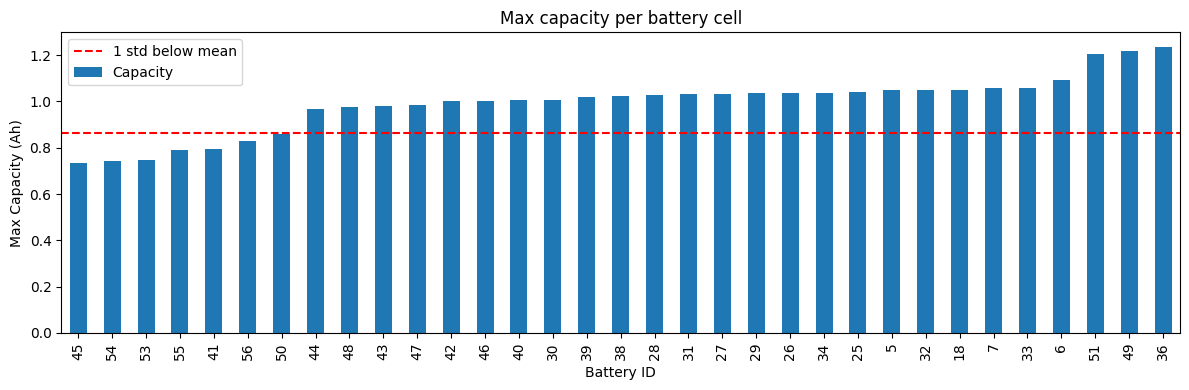

Kept 23 of 33 cells
Rows: 1472


In [36]:
import matplotlib.pyplot as plt

max_cap = merged.groupby('battery_id')['Capacity'].max().sort_values()
print(max_cap)
print(f'\nMean: {max_cap.mean():.3f}')
print(f'Std:  {max_cap.std():.3f}')

max_cap.plot(kind='bar', figsize=(12,4))
plt.axhline(y=max_cap.mean() - max_cap.std(), color='red', linestyle='--', label='1 std below mean')
plt.xlabel('Battery ID')
plt.ylabel('Max Capacity (Ah)')
plt.title('Max capacity per battery cell')
plt.legend()
plt.tight_layout()
plt.show()

# Keep only cells within 1 std of the mean max capacity
mean_cap = max_cap.mean()
std_cap  = max_cap.std()

valid_cells = max_cap[(max_cap >= mean_cap - std_cap) & 
                      (max_cap <= mean_cap + std_cap)].index

merged_clean = merged[merged['battery_id'].isin(valid_cells)].copy()
merged = merged_clean.copy().reset_index(drop=True)
print(f'Kept {len(valid_cells)} of {len(max_cap)} cells')
print(f'Rows: {len(merged_clean)}')

Feature Engineering

Derives four new features from the merged data to make degradation patterns more learnable: voltage_range (max capacity minus current capacity), capacity_fade (cycle-over-cycle capacity change via diff), cumulative_fade (running total of capacity changes), and total_impedance (Re + Rct combined). Saves the result to nasa_processed.csv, then generates two diagnostic plots — a correlation heatmap of all key features and a SoH-vs-test-id degradation curve for every battery cell with threshold lines at 90 % and 80 %.

In [37]:
#Feature Engineering: make patterns more apprent for ML model to learn from.
#Use domain knowledge to transform raw data into meangingful features that capture the degradation patterns more clearly.

#Voltage and resistance:
merged['voltage_range'] = merged.groupby('battery_id')['Capacity'].transform(
    lambda x: x.max() - x
    #new column named "voltage_range" = maximum capacity for that battery - current capacity at each test_id
)

#Capacity fade rate cycle-over-cycle
#fade rate = change in capacity from one cycle to the next. 
# This can help capture how quickly the battery is degrading over time, which may be more informative than just the raw capacity values.
merged['capacity_fade'] = merged.groupby('battery_id')['Capacity'].transform(
    lambda x: x.diff().fillna(0)  
    #new column named "capacity_fade" = difference in capacity from one test_id to the next for each battery, with NaN values filled with 0 (for the first test_id where there is no previous value to compare to)
)

#cumulative fade so far
merged['cumulative_fade'] = merged.groupby('battery_id')['Capacity'].transform(
    lambda x: x.cumsum().abs() 
    #column named 'cumulative_fade' = cumulative sum of the capacity changes, taking the absolute value to capture total degradation regardless of direction
)

#Re + Rct combined - total impedance rise
merged['total_impedance'] = merged['Re'] + merged['Rct']

print(merged[['Re', 'Rct', 'total_impedance', 'capacity_fade', 'cumulative_fade']].describe())

#--------------SAVE PROCESSED DATA----------------
merged.to_csv('nasa_processed.csv', index=False) #Save the merged DataFrame to a new CSV file named 'nasa_processed.csv' without including the index column.
print('Saved. Shape: ', merged.shape) #Print a confirmation message with the shape of the saved DataFrame to verify that it was saved correctly.
print(merged.columns.tolist()) #Print the list of column names in the merged DataFrame to verify that all expected columns are present after processing.



                Re          Rct  total_impedance  capacity_fade  \
count  1472.000000  1472.000000      1472.000000    1472.000000   
mean      0.069223     0.103994         0.173217      -0.000125   
std       0.022316     0.040685         0.056673       0.100301   
min       0.027270     0.038781         0.066533      -0.873876   
25%       0.054093     0.075598         0.132000      -0.002448   
50%       0.064301     0.089352         0.155129       0.000000   
75%       0.076093     0.123217         0.215437       0.000000   
max       0.136970     0.218988         0.300388       0.866349   

       cumulative_fade  
count      1472.000000  
mean         72.797839  
std          71.304238  
min           0.066186  
25%          15.548001  
50%          40.617974  
75%         126.680913  
max         241.403366  
Saved. Shape:  (1472, 12)
['battery_id', 'test_id', 'Capacity', 'ambient_temperature', 'Re', 'Rct', 'SoH', 'fault_tier', 'voltage_range', 'capacity_fade', 'cumulative_fade

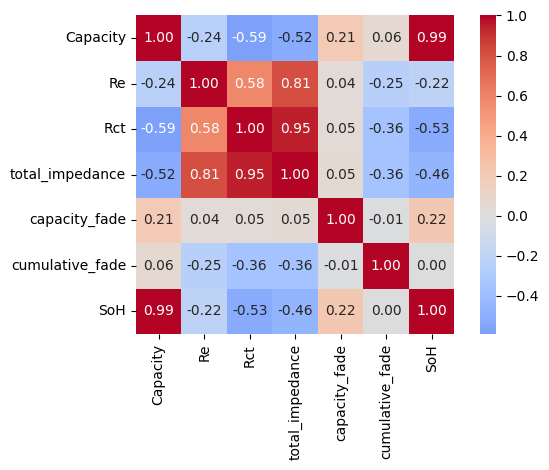

'Key insights from the correlation heatmap:\n        1.00 = perfect positive relation\n        -1.00 = perfect negative relation\n        0 = no relation\n\n        red = positive correlation\n        blue = negative correlation\n        white = no correlation\n\n- Capacity has a perfect positive correlation with SoH (1.00).\n- Re and Rct have strong positive correlation w/ total impedance (0.90 and 0.95 respectively).\n\n- Capacity has moderate negative correlation w/ Rct (-0.50)\n    As battery ages, Rct increases and capacity drops\n- Capacity has moderate negative correlation w/ total impedance (-0.39)\n    higher impedance = more degradation = lower capacity\n- Capacity has weak negative correlation w/ Re (-0.18).\n\n- SoH has moderate negative correlation w/ Rct (-0.46)\n    higher charge-transfer resistance = more degradation = lower SoH = worse health\n- SoH has moderate negative correlation w/ total impedance (-0.35)\n\n- capacity_fade has a weak positive correlation with Capa

In [38]:

# --- CORRELATION HEATMAP (5 min) ------------------------------------------------------------------
#This code block is creating a correlation heatmap to visualize the relationships between key features in the merged DataFrame.
import seaborn as sns

feat_cols = ['Capacity','Re','Rct','total_impedance','capacity_fade','cumulative_fade','SoH']
corr = merged[feat_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()

'''Key insights from the correlation heatmap:
        1.00 = perfect positive relation
        -1.00 = perfect negative relation
        0 = no relation

        red = positive correlation
        blue = negative correlation
        white = no correlation

- Capacity has a perfect positive correlation with SoH (1.00).
- Re and Rct have strong positive correlation w/ total impedance (0.90 and 0.95 respectively).

- Capacity has moderate negative correlation w/ Rct (-0.50)
    As battery ages, Rct increases and capacity drops
- Capacity has moderate negative correlation w/ total impedance (-0.39)
    higher impedance = more degradation = lower capacity
- Capacity has weak negative correlation w/ Re (-0.18).

- SoH has moderate negative correlation w/ Rct (-0.46)
    higher charge-transfer resistance = more degradation = lower SoH = worse health
- SoH has moderate negative correlation w/ total impedance (-0.35)

- capacity_fade has a weak positive correlation with Capacity (0.19) and SoH (0.20).
- cumulative_fade has weak negative correlation with Re (-0.31), Rct (-0.31), and total impedance (-0.33).

'''



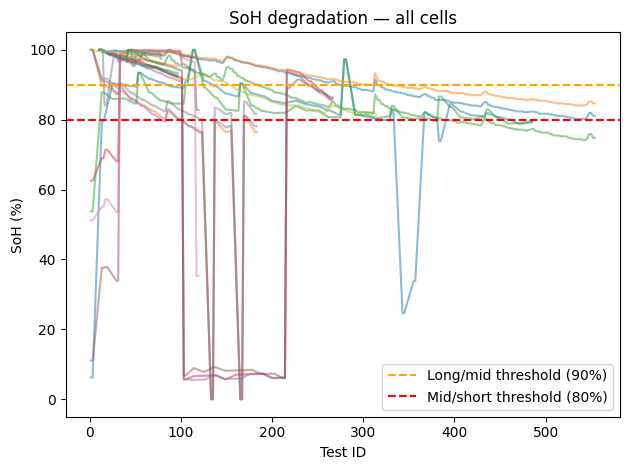

In [39]:
# --- CAPACITY DEGRADATION PLOT (5 min) ---
#This code block is plotting the State of Health (SoH) degradation over time for each battery cell in the merged DataFrame.
for cell_id in merged['battery_id'].unique():
    cell = merged[merged['battery_id'] == cell_id].sort_values('test_id')
    plt.plot(cell['test_id'], cell['SoH'], alpha=0.5)

plt.axhline(y=90, color='orange', linestyle='--', label='Long/mid threshold (90%)')
plt.axhline(y=80, color='red',    linestyle='--', label='Mid/short threshold (80%)')
plt.xlabel('Test ID')
plt.ylabel('SoH (%)')
plt.title('SoH degradation — all cells')
plt.legend()
plt.tight_layout()
plt.savefig('soh_degradation.png')
plt.show()

#All cells are degrading over time at different rates.
#They all start at 100% SoH, but some degrade much faster than others. 
# The orange and red dashed lines show the thresholds for the fault tiers we defined earlier. 
# We can see that some cells drop below 80% SoH (short tier) much sooner than others, while some remain above 90% (long tier) for most of the test period. 
# This variability in degradation patterns is important for training our ML model to recognize different types of faults and predict remaining useful life accurately.


Add gas + smoke sensor channels to nasa_processed.csv

In [41]:
# this cell is for generating synthetic gas and smoke data based on the existing features in the merged DataFrame, 
# using domain knowledge about how these measurements typically relate to battery degradation.

import numpy as np

df = pd.read_csv('nasa_processed.csv')

if 'gas_ppm' not in df.columns:
    np.random.seed(42)

    #gas starts earlier, grows strongly and has physical link to internal chemistry (Rct)
    df['gas_ppm'] = (
        120
        + 15 * np.exp((100 - df['SoH']) / 8) #smoother exponential curve to reflect gradual increase in gas emissions as battery degrades, with sharper rise as SoH drops below 80%
        + 5*df['Rct']   #link to internal chemistry
        + np.random.normal(0, 3, len(df))
    ).clip(lower=0)

    #smoke is a late-event trigger, not continuously rising like gas. It appears more suddenly as the battery approaches failure, and is also linked to internal chemistry (Rct).
    df['smoke_density'] = (
        0.02
        + 0.005 * (100 - df['SoH'])
        + 0.1 * df['Rct']
    )

    #sharp spike only when battery is close to failure (SoH < 70%), with some random noise to reflect real-world variability in smoke detection
    df.loc[df['SoH'] < 70, 'smoke_density'] += np.random.uniform(0.3, 0.6, size=(df['SoH'] < 70).sum())
    
    df['smoke_density'] += np.random.normal(0, 0.01, len(df))
    df['smoke_density'] = df['smoke_density'].clip(lower=0)

    df.to_csv('nasa_processed.csv', index=False)
    print('Saved with gas + smoke. Shape:', df.shape)
    print(df[['gas_ppm','smoke_density']].describe())

    # .describe() will give us the count, mean, std, min, 25th percentile, median, 75th percentile, and max values for the 'gas_ppm' and 'smoke_density' columns in the DataFrame.
    # This allows us to understand the distribution of the synthetic gas and smoke data we generated, including the average levels, variability, and range of values.

Saved with gas + smoke. Shape: (1472, 14)
            gas_ppm  smoke_density
count  1.472000e+03    1472.000000
mean   1.109570e+05       0.141265
std    5.038433e+05       0.217690
min    1.293671e+02       0.006449
25%    1.453452e+02       0.049234
50%    1.839844e+02       0.087462
75%    2.621814e+02       0.121581
max    4.025187e+06       1.095369


Normalize all 8 features, save scaler.pkl

In [ ]:
# --- FEATURE SCALING + SAVE PIPELINE (5 min) ---
# Normalizing features to have mean ~0 and std ~1, which helps many ML models converge faster and perform better.
# We will also save the fitted scaler object to disk using joblib, so we can apply the same scaling to new data when we deploy the model.

''' 
Formula for standardization (z-score normalization): 
it transforms the raw feature values into a standardized scale where 
the mean of the feature = 0 and the standard deviation = 1.

scaled_value = (raw_value - mean) / std 
''' 
#important to use the same scaler for both training and inference to ensure consistency in how the features are transformed.

from sklearn.preprocessing import StandardScaler
import joblib
from pathlib import Path

Path('pipeline').mkdir(exist_ok=True)

SENSOR_FEATURES = [
    'Re', 'Rct', 'total_impedance',
    'capacity_fade', 'cumulative_fade',
    'ambient_temperature', 'gas_ppm', 'smoke_density'
]

X_raw = df[SENSOR_FEATURES]
y     = df['fault_tier']

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X_raw), columns=SENSOR_FEATURES)

joblib.dump(scaler, 'pipeline/scaler.pkl')
print('Means (should be ~0):', X.mean().round(3).values)
print('Stds  (should be ~1):', X.std().round(3).values)

Plots to explore relationships between sensors.

The three scatter plots show that the added sensor features are separating the fault states pretty well.

In the left plot, gas level generally rises as total impedance increases, and the highest gas readings are mostly the low-SoH points. That means the synthetic gas signal is behaving like a degradation indicator.

In the middle plot, smoke density stays near the bottom for most samples, but it jumps for the most degraded cases. So this feature is weaker overall, but it still lights up for severe wear.

In the right plot, the classes separate cleanly by gas level: long batteries cluster at low gas, mid batteries sit in the middle, and short batteries have the highest gas readings. That is the strongest visual sign that the new features are useful

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sc1 = axes[0].scatter(df['total_impedance'], df['gas_ppm'],
    c=df['SoH'], cmap='RdYlGn', alpha=0.5, s=15)
plt.colorbar(sc1, ax=axes[0], label='SoH (%)')
axes[0].set_xlabel('Total impedance (Ω)')
axes[0].set_ylabel('Gas level (ppm)')
axes[0].set_title('Gas vs impedance (colored by SoH)')

sc2 = axes[1].scatter(df['cumulative_fade'], df['smoke_density'],
    c=df['SoH'], cmap='RdYlGn', alpha=0.5, s=15)
plt.colorbar(sc2, ax=axes[1], label='SoH (%)')
axes[1].set_xlabel('Cumulative capacity fade (Ah)')
axes[1].set_ylabel('Smoke density')
axes[1].set_title('Smoke vs capacity fade')

for tier, grp in df.groupby('fault_tier'):
    axes[2].scatter(grp['SoH'], grp['gas_ppm'],
        label=tier, alpha=0.4, s=15)
axes[2].set_xlabel('SoH (%)')
axes[2].set_ylabel('Gas (ppm)')
axes[2].set_title('Gas level by fault tier')
axes[2].legend()

from pathlib import Path
Path('data').mkdir(exist_ok=True)

plt.tight_layout()
plt.savefig('data/cross_sensor_analysis.png', dpi=150)
plt.show()

The confusion matrix shows the classifier is performing well on the 3 fault tiers. The diagonal counts are the correct predictions: 126 long, 113 mid, and 45 short, for 284 correct out of 295 total, which is about 96.3% accuracy. 

    The mistakes are small and mostly between neighboring classes:
        long is sometimes predicted as mid 4 times.
        mid is predicted as long 5 times and short 1 time.
        short is predicted as mid once.

That pattern means the model is mainly confusing adjacent health states, which is expected. It is not mixing healthy and badly degraded batteries very often, so the class boundaries are working reasonably well.

RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

#Random Forest is used here for
#    Classification, because we are predicting discrete fault tiers (long, mid, short) rather than a continuous value.
#    n_estimators=100 means it will use 100 decision trees in the random forest ensemble. 
#    As the battery degrades, the model can learn from multiple "weak learners" (individual trees) to make a stronger overall prediction about the fault tier based on the sensor features.

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc) #80-20 split, 80% for training, 20% for testing.

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
    xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion matrix — 8-sensor model')
plt.savefig('data/confusion_matrix_v2.png', dpi=150)
plt.show()

joblib.dump(clf, 'pipeline/classifier.pkl')
joblib.dump(le,  'pipeline/label_encoder.pkl')
print('Saved updated classifier.')

#precision: of all the samples that the model predicted as a certain class (e.g., 'short'), how many of them were actually that class in the test
#recall: of all the samples that actually belong to a certain class (e.g., 'short'), how many of them did the model correctly identify as that class in its predictions
#f1-score: the harmonic mean of precision and recall, providing a single metric that balances both false positives and false negatives.
